# Analiza eksploracyjna

## Importy

In [70]:
import pandas as pd
import numpy as np
import pickle
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

## Wczytanie danych

In [71]:
df = pd.read_csv("data/historical_for_eda.csv", parse_dates=['date'])

## Analiza kompletności danych

In [72]:
df

,date,avg_temp,min_temp,max_temp,precipitation_total_mm,snow,wind_direction,average_wind_speed,max_wind_speed,pressure_hpa,sunshine_total_min,station_name
0,2020-01-01,-1.7,-4.6,0.1,NaN,NaN,NaN,6.8,18.5,1033.2,NaN,Zakopane
1,2020-01-02,-1.7,-5.4,5.6,NaN,NaN,NaN,5.6,13.0,1031.1,NaN,Zakopane
2,2020-01-03,-1.4,-6.0,5.8,NaN,NaN,NaN,4.6,22.2,1025.6,NaN,Zakopane
3,2020-01-04,0.7,-2.4,4.5,NaN,NaN,NaN,13.2,33.3,1020.9,NaN,Zakopane
4,2020-01-05,-4.1,-5.1,-2.5,NaN,NaN,NaN,8.9,31.5,1029.3,NaN,Zakopane
...,...,...,...,...,...,...,...,...,...,...,...,...
4379,2025-12-27,-5.6,-10.3,1.3,0.0,NaN,NaN,12.2,NaN,1021.8,NaN,Kasprowy Wierch
4380,2025-12-28,-12.9,-14.6,-10.6,1.1,NaN,NaN,23.7,NaN,1022.6,NaN,Kasprowy Wierch
4381,2025-12-29,-11.5,-14.7,-7.8,0.0,NaN,NaN,17.7,NaN,1016.0,NaN,Kasprowy Wierch
4382,2025-12-30,-14.7,-17.1,-11.3,4.4,NaN,NaN,19.2,NaN,1015.0,NaN,Kasprowy Wierch


In [73]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4384 entries, 0 to 4383
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   date                    4384 non-null   datetime64[us]
 1   avg_temp                4384 non-null   float64       
 2   min_temp                4358 non-null   float64       
 3   max_temp                4358 non-null   float64       
 4   precipitation_total_mm  3093 non-null   float64       
 5   snow                    0 non-null      float64       
 6   wind_direction          0 non-null      float64       
 7   average_wind_speed      4384 non-null   float64       
 8   max_wind_speed          2181 non-null   float64       
 9   pressure_hpa            3997 non-null   float64       
 10  sunshine_total_min      0 non-null      float64       
 11  station_name            4384 non-null   str           
dtypes: datetime64[us](1), float64(10), str(1)
memory usage: 411

### Wniosek 1

Brak pomiarów dla snow, wind_direction, sunshine_total_min --> usuwamy z danych

In [74]:
df = df.drop(["snow", "wind_direction", "sunshine_total_min"], axis=1, errors="ignore")

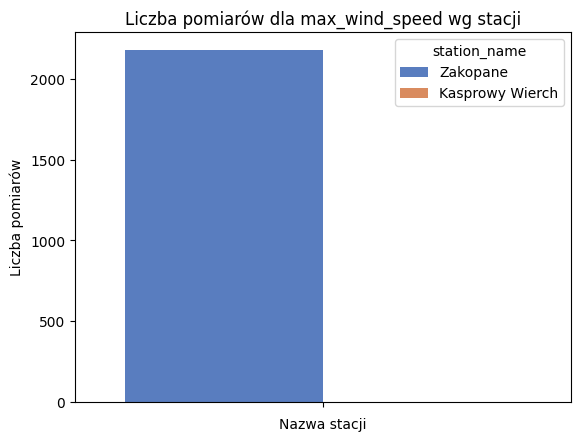

In [75]:
sns.barplot(df, 
            hue="station_name", 
            y="max_wind_speed", 
            estimator=len,
            palette="muted")

plt.title("Liczba pomiarów dla max_wind_speed wg stacji")
plt.ylabel("Liczba pomiarów")
plt.xlabel("Nazwa stacji");

### Wniosek 2

Pomiar max_wind_speed jest dostępny tylko dla stacji Zakopane. Usuwamy z danych ze względu na brak możliwości porównania.

In [76]:
df = df.drop(["max_wind_speed"], axis=1, errors="ignore")

In [77]:
numeric_columns = list(df.columns)
numeric_columns.remove('date')

In [78]:
df[numeric_columns].describe()

,avg_temp,min_temp,max_temp,precipitation_total_mm,average_wind_speed,pressure_hpa
count,4384.000000,4358.000000,4358.000000,3093.000000,4384.000000,3997.000000
mean,4.155908,0.747040,7.774438,3.605011,13.265990,1017.937603
std,8.198695,7.670303,9.146588,5.861420,11.017949,7.941954
min,-23.100000,-24.600000,-21.500000,0.000000,1.600000,991.000000
25%,-1.900000,-4.700000,0.700000,0.000000,4.800000,1013.100000
50%,4.000000,0.600000,7.500000,1.100000,9.200000,1018.100000
75%,10.400000,6.600000,14.575000,4.800000,18.400000,1022.800000
max,24.700000,19.300000,30.900000,71.400000,62.200000,1045.700000


## Analiza porównawcza

### ogólna statystyka

In [79]:
df[df["date"].dt.year.isin([2023, 2024, 2025])][numeric_columns].describe()

,avg_temp,min_temp,max_temp,precipitation_total_mm,average_wind_speed,pressure_hpa
count,2192.000000,2192.000000,2192.000000,2146.000000,2192.000000,2173.000000
mean,4.628558,1.171578,8.220849,3.639329,12.915328,1017.583985
std,8.132173,7.567961,9.089919,6.041436,10.893705,7.949455
min,-17.500000,-19.800000,-16.300000,0.000000,1.700000,991.000000
25%,-1.600000,-4.300000,1.000000,0.000000,4.700000,1012.800000
50%,4.700000,1.200000,8.000000,1.050000,9.000000,1017.700000
75%,11.000000,6.900000,15.200000,4.800000,17.600000,1022.400000
max,22.700000,19.000000,30.600000,71.400000,62.200000,1045.700000


### Porównanie stacji wg średniej dobowej temperatury

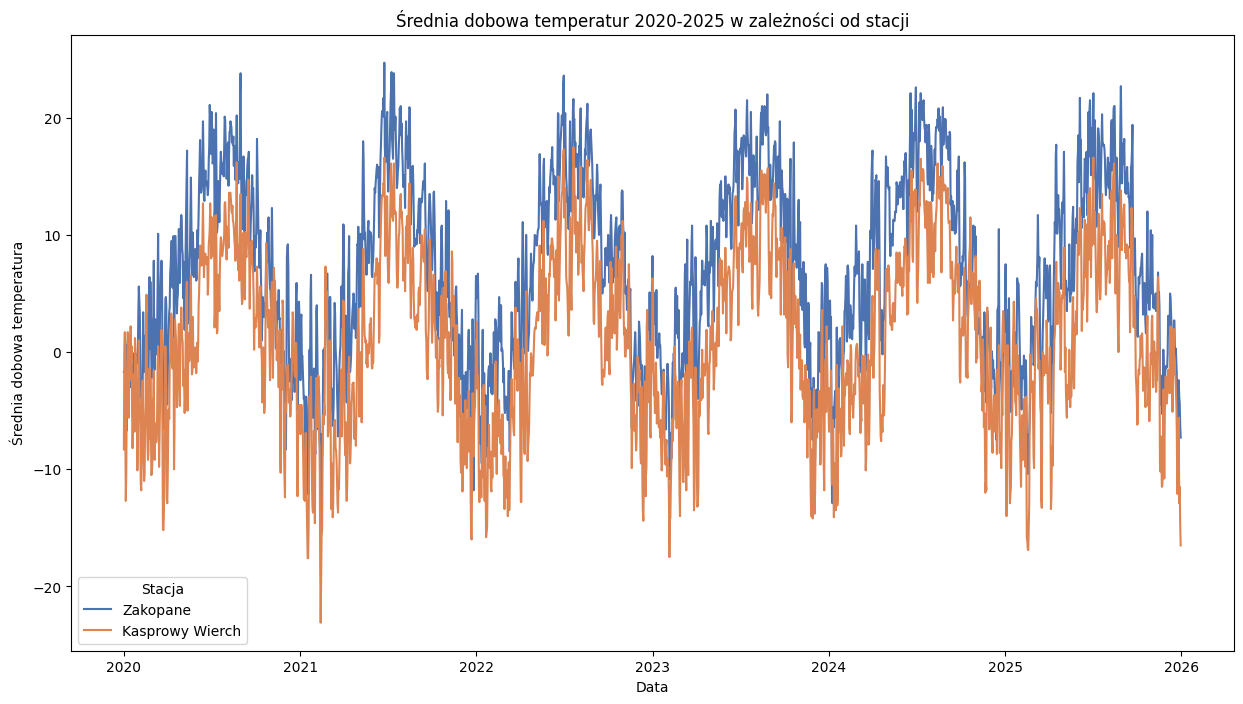

In [80]:
plt.figure(figsize=(15, 8))
sns.lineplot(df, 
             x="date", 
             y="avg_temp", 
             hue="station_name", 
             palette="deep")

plt.title("Średnia dobowa temperatur 2020-2025 w zależności od stacji")
plt.ylabel("Średnia dobowa temperatura")
plt.legend(title="Stacja")
plt.xlabel("Data");

### Liczba dni z temperaturą pow. 20

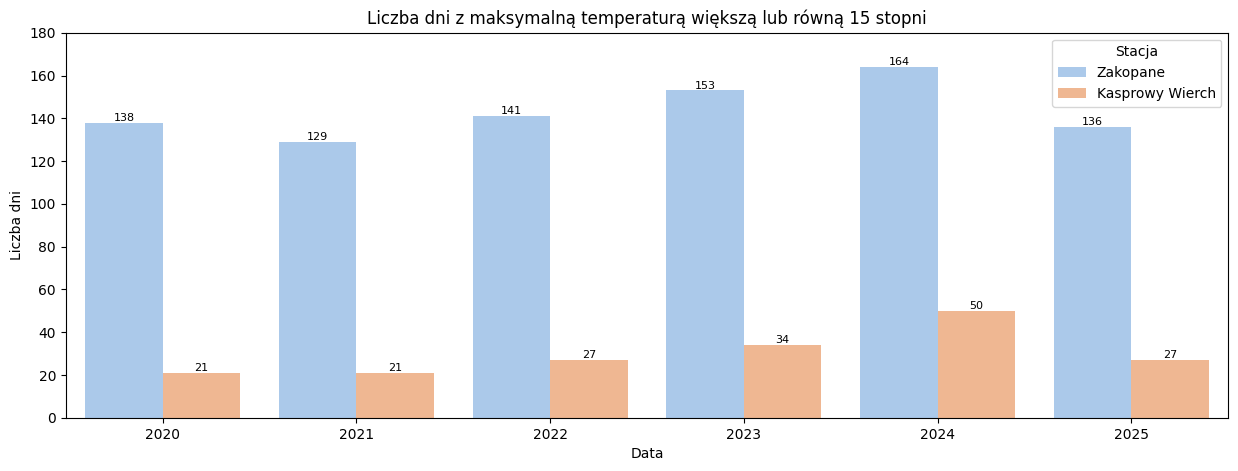

In [81]:
plt.figure(figsize=(15, 5))
ax = sns.countplot(df[df["max_temp"]>=15], 
              x=df["date"].dt.year,
              hue="station_name", 
              palette="pastel")
plt.title("Liczba dni z maksymalną temperaturą większą lub równą 15 stopni")
plt.ylabel("Liczba dni")
plt.legend(title="Stacja")
plt.xlabel("Data")
plt.ylim(0, 180)

for c in ax.containers:
    ax.bar_label(c, fmt='%d', fontsize=8);

### Korelacja między warunkami pogodowymi

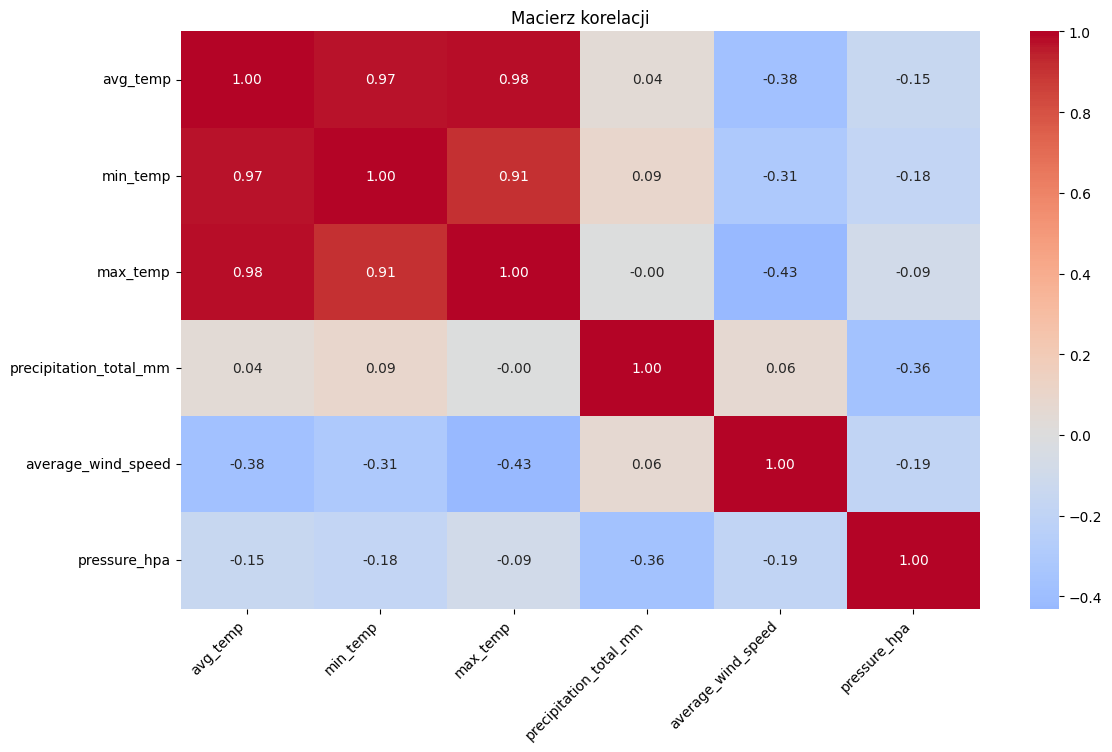

In [82]:
corr = df.select_dtypes(include="number").corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Macierz korelacji")
plt.tight_layout()
plt.xticks(rotation=45, ha="right")
plt.show()